In [2]:
import pandas as pd
import numpy as numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv to Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv


In [3]:
df = pd.read_csv('Foodpanda Analysis Dataset (1) - Foodpanda Analysis Dataset (1).csv')
df.head()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,1/14/2024,O9663,8/23/2023,McDonald's,Burger,Italian,5,1478.27,Cash,38,7/19/2025,238,Active,3,10/14/2024,Cancelled
1,C2831,Male,Adult,Multan,7/7/2024,O6831,8/23/2023,KFC,Burger,Italian,3,956.04,Wallet,24,11/25/2024,81,Active,2,8/21/2025,Delayed
2,C2851,Other,Senior,Multan,6/20/2025,O6851,8/23/2023,Pizza Hut,Fries,Italian,2,882.51,Cash,42,5/10/2025,82,Inactive,3,9/19/2024,Delayed
3,C1694,Female,Senior,Peshawar,9/5/2023,O5694,8/23/2023,Subway,Pizza,Dessert,4,231.30,Card,27,7/24/2025,45,Inactive,2,6/29/2025,Delayed
4,C4339,Other,Senior,Lahore,12/29/2023,O8339,8/24/2023,KFC,Sandwich,Dessert,1,1156.69,Cash,35,12/21/2024,418,Inactive,3,3/6/2025,Cancelled


# **Part B: Python + Pandas**

1. Load the file. Show the shape, the first 5 rows, and info().

In [4]:
df.shape

(6000, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

In [6]:
df.shape

(6000, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      6000 non-null   object 
 1   gender           6000 non-null   object 
 2   age              6000 non-null   object 
 3   city             6000 non-null   object 
 4   signup_date      6000 non-null   object 
 5   order_id         6000 non-null   object 
 6   order_date       6000 non-null   object 
 7   restaurant_name  6000 non-null   object 
 8   dish_name        6000 non-null   object 
 9   category         6000 non-null   object 
 10  quantity         6000 non-null   int64  
 11  price            6000 non-null   float64
 12  payment_method   6000 non-null   object 
 13  order_frequency  6000 non-null   int64  
 14  last_order_date  6000 non-null   object 
 15  loyalty_points   6000 non-null   int64  
 16  churned          6000 non-null   object 
 17  rating        

2. Find the missing values in each column. Handle them and remove duplicate rows. Add one
comment explaining why you chose that method.

In [8]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
city,0
signup_date,0
order_id,0
order_date,0
restaurant_name,0
dish_name,0
category,0


In [10]:
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Median is used for numeric columns .
# Mode is used for categorical columns because it replaces missing values with the most common category.

In [11]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
city,0
signup_date,0
order_id,0
order_date,0
restaurant_name,0
dish_name,0
category,0


In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(6000, 20)

In [15]:
df.duplicated().sum()

np.int64(0)

3. Create a new column total_sales = price × quantity.


In [16]:
df["total_sales"] = df["price"] * df["quantity"]
df[["price", "quantity", "total_sales"]].head()

,price,quantity,total_sales
0,1478.27,5,7391.35
1,956.04,3,2868.12
2,882.51,2,1765.02
3,231.30,4,925.20
4,1156.69,1,1156.69


4. Find the top 3 best-selling dishes (by total of total_sales) and the average rating per category.

In [36]:
top_3_dishes = (
    df.groupby("dish_name")["total_sales"].sum().sort_values(ascending=False).head(3)
)

print("Top 3 Best-Selling Dishes:")
print(top_3_dishes)

Top 3 Best-Selling Dishes:
dish_name
Pasta       3078850.36
Sandwich    2966591.11
Pizza       2782227.05
Name: total_sales, dtype: float64


In [19]:
avg_rating_category = df.groupby("category")["rating"].mean()

print("Average Rating per Category:")
print(avg_rating_category)

Average Rating per Category:
category
Chinese        3.006678
Continental    2.997523
Dessert        3.050309
Fast Food      2.954992
Italian        2.978964
Name: rating, dtype: float64


5. Write a function rating_label(r) that returns "Good" (rating 4-5), "Average" (rating 3) or "Poor"
(rating 1-2). Apply it to the rating column and save the result in a new column.

In [20]:
def rating_label(r):
    if r >= 4:
        return "Good"
    elif r == 3:
        return "Average"
    else:
        return "Poor"

df["rating_label"] = df["rating"].apply(rating_label)

df[["rating", "rating_label"]].head()

,rating,rating_label
0,3,Average
1,2,Poor
2,3,Average
3,2,Poor
4,3,Average


# **Part C: Visualization + Statistics**

1. Draw a bar chart of total sales by category, with a title and axis labels.

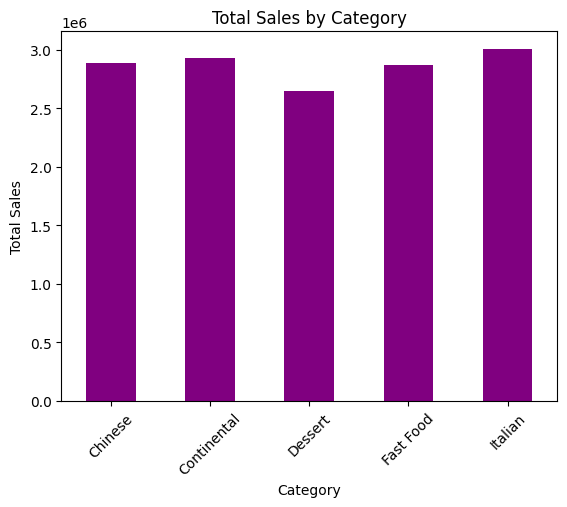

In [37]:
sales_by_category = df.groupby("category")["total_sales"].sum()
sales_by_category.plot(kind="bar", color= "purple")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

2. Draw a histogram of price, with a title and axis labels.

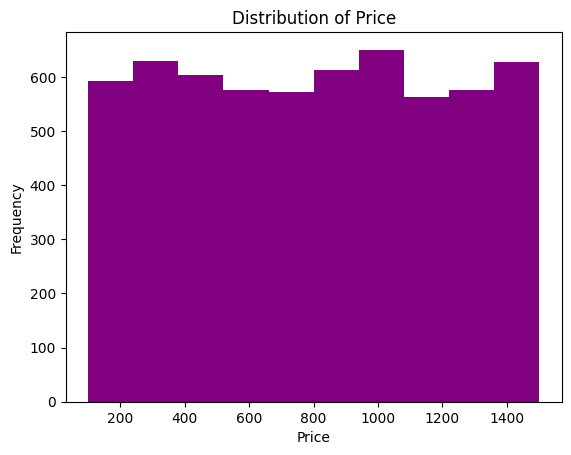

In [38]:
plt.hist(df["price"], bins=10, color = "purple")

plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

3. Calculate the mean, median and standard deviation of total_sales. Write 2 sentences
interpreting them.

In [23]:
mean_sales = df["total_sales"].mean()
median_sales = df["total_sales"].median()
std_sales = df["total_sales"].std()

print("Mean:", mean_sales)
print("Median:", median_sales)
print("Standard Deviation:", std_sales)

Mean: 2390.6520133333333
Median: 1901.5749999999998
Standard Deviation: 1754.874758108934


The mean total sales is 2390.65, while the median is 1901.57, showing the typical sales value and the central tendency of the data.
The standard deviation is 1754.87, indicating how much the total sales values vary around the mean.

4. Draw a scatter plot of price vs total_sales. Write one sentence about what you see.

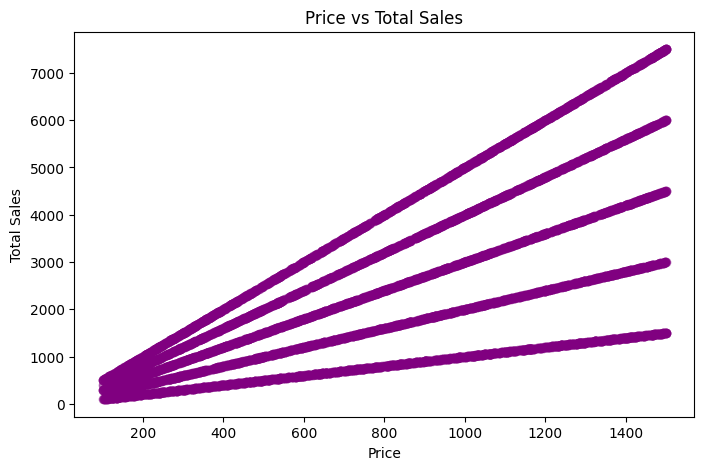

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(df["price"], df["total_sales"], alpha=0.5, color = "purple")
plt.xlabel("Price")
plt.ylabel("Total Sales")
plt.title("Price vs Total Sales")
plt.show()

# **Part D: Mini ML**

1. Use Linear Regression to predict total_sales from price, quantity and order_frequency. Do the
train/test split (80/20, random_state=42), fit the model and predict on the test set.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [29]:
# Select features and target
X = df[["price", "quantity", "order_frequency"]]
y = df["total_sales"]

In [30]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test)

In [33]:
print("Predicted Total Sales:")
print(y_pred)

Predicted Total Sales:
[3176.31541385 2253.41771899 -122.78192297 ... 2773.84141533 1895.26425412
 -148.58523389]


2. Report R2 or MAE on the test set.

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("R² Score:", r2)
print("MAE:", mae)

R² Score: 0.8935614191167981
MAE: 412.1652062676387


3. In 3 lines, explain in plain language what your result means.

The R² score shows how well the model predicts total sales from price, quantity, and order frequency.
A higher R² means the model gives better predictions.
The MAE shows the average difference between the actual sales and the predicted sales.


In [48]:
from sklearn.metrics import classification_report

In [49]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.25      0.33      0.29         3
           2       0.75      0.60      0.67         5

    accuracy                           0.55        11
   macro avg       0.56      0.53      0.54        11
weighted avg       0.59      0.55      0.56        11

